In [ ]:
import pandas as pd

In [7]:
data = pd.read_csv('data/GSE115469_Data.csv', index_col=0)
cell_cluster_data = pd.read_csv('data/GSE115469_CellClusterType.txt', sep='\t')

# Pretprocesiranje - opsti koraci

In [8]:
gene_frequency = (data > 0).mean(axis=1)
data = data.loc[gene_frequency >= 0.05]

In [9]:
gene_var = data.var(axis=1)
gene_var_sorted = gene_var.sort_values(ascending=False)
gene_var_keep = gene_var_sorted[:2000]

In [10]:
data = data.loc[gene_var_keep.index]

In [11]:
data = data.clip(upper=data.quantile(0.999).max())

In [12]:
data = data.T

# PRETPROCESIRANJE - Klasifikacija

## Korak 1: Spajanje tabela
Za potrebe klasifikacije bilo je neophodno objediniti informacije iz dve različite tabele. Jedna tabela sadržala je metapodatke o ćelijama, uključujući identifikator ćelije (CellName), uzorak (Sample), broj ćelije (Cell#), klaster kojem ćelija pripada (Cluster#) i stvarni tip ćelije (CellType), dok je druga sadržala podatke o ekspresiji gena dobijene primenom single-cell RNA-seq metode, pri čemu su za svaku ćeliju zabeležene vrednosti ekspresije velikog broja gena.

Pošto obe tabele sadrže jedinstveni identifikator ćelije (CellName), izvršeno je njihovo spajanje korišćenjem ovog atributa kao zajedničkog ključa. Na taj način je za svaku ćeliju formiran jedinstven zapis koji istovremeno sadrži informacije o ekspresiji gena i odgovarajući tip ćelije.

Spajanje tabela predstavlja neophodan korak za klasifikaciju, jer se ciljna promenljiva (CellType) nalazi u tabeli sa metapodacima, dok se atributi koji služe za predikciju nalaze u tabeli ekspresije gena. Tek nakon objedinjavanja podataka moguće je formirati skup podataka pogodan za primenu algoritama klasifikacije.

In [13]:
data.index.name = 'CellName'
data.reset_index(inplace=True)

In [14]:
data.head()

,CellName,APOC3,APOA2,ORM1,HP,ALB,APOC1,TTR,SAA1,APOA1,...,HMGCR,RNF149,GIMAP1,APH1A,MAF1,TACC1,PDXDC1,FUNDC2,RNF167,PSAT1
0,P1TLH_AAACCTGAGCAGCCTC_1,0.836165,0.836165,0.000000,1.362102,0.000000,0.836165,0.000000,1.362102,0.836165,...,0.0,0.000000,0.000000,0.000000,0.0,0.836165,0.0,0.000000,0.0,0.0
1,P1TLH_AAACCTGTCCTCATTA_1,1.436498,1.436498,3.458904,1.149924,4.797971,2.059859,0.572995,2.493720,1.300315,...,0.0,0.000000,0.000000,0.314760,0.0,0.982011,0.0,0.000000,0.0,0.0
2,P1TLH_AAACCTGTCTAAGCCA_1,1.820614,0.000000,0.000000,1.180248,0.000000,0.000000,1.180248,0.000000,0.000000,...,0.0,0.000000,0.000000,0.000000,0.0,1.180248,0.0,1.180248,0.0,0.0
3,P1TLH_AAACGGGAGTAGGCCA_1,0.000000,0.644905,0.000000,0.000000,0.000000,0.000000,0.000000,1.428094,0.000000,...,0.0,1.428094,0.644905,0.644905,0.0,0.000000,0.0,0.000000,0.0,0.0
4,P1TLH_AAACGGGGTTCGGGCT_1,1.284221,1.284221,0.780522,1.656843,1.656843,0.780522,0.000000,1.656843,0.780522,...,0.0,0.000000,1.284221,0.780522,0.0,0.000000,0.0,0.000000,0.0,0.0


In [15]:
merged_data = pd.merge(
    data,
    cell_cluster_data,
    on='CellName'
)

In [16]:
merged_data.columns

Index(['CellName', 'APOC3', 'APOA2', 'ORM1', 'HP', 'ALB', 'APOC1', 'TTR',
       'SAA1', 'APOA1',
       ...
       'MAF1', 'TACC1', 'PDXDC1', 'FUNDC2', 'RNF167', 'PSAT1', 'Sample',
       'Cell#', 'Cluster#', 'CellType'],
      dtype='object', length=2005)

In [17]:
merged_data.shape

(8444, 2005)

## Korak 2: Izdvajanje ulaznih i ciljnih atributa
Nakon spajanja tabela izvršeno je izdvajanje *ulaznih atributa (feature-a)* i *ciljne promenljive (target-a)*. Kao ciljna promenljiva izabran je atribut **CellType**, koji predstavlja stvarni tip ćelije i koji klasifikacioni modeli treba da predvide na osnovu podataka o ekspresiji gena.

Ulazne atribute činile su vrednosti ekspresije gena dobijene iz single-cell RNA-seq podataka. Svaki gen predstavlja jedan atribut, dok svaka vrsta predstavlja jednu ćeliju.

Iz skupa ulaznih atributa uklonjeni su sledeći atributi:

**CellName** – predstavlja jedinstveni identifikator ćelije i ne sadrži biološku informaciju relevantnu za određivanje tipa ćelije  
**Sample** – označava uzorak iz kog ćelija potiče i ne predstavlja karakteristiku same ćelije  
**Cell#** – redni broj ćelije, koji nema prediktivnu vrednost  
**Cluster#** – oznaka klastera dobijena prethodnim postupkom grupisanja ćelija

Atribut Cluster# je posebno uklonjen kako bi se izbeglo curenje informacija. Pošto su klasteri formirani na osnovu obrazaca genske ekspresije, uključivanje ove informacije moglo bi veštački da poveća uspešnost klasifikacije i dovede do nerealno optimističnih rezultata. Cilj klasifikacije je da model nauči da razlikuje tipove ćelija isključivo na osnovu ekspresije gena, bez korišćenja unapred izvedenih informacija.

Nakon uklanjanja navedenih atributa, skup ulaznih podataka sadržao je isključivo vrednosti ekspresije gena, dok je atribut CellType korišćen kao ciljna promenljiva za treniranje i evaluaciju klasifikacionih modela.

In [66]:
X = merged_data.drop(columns=['CellName', 'Cell#', 'CellType', 'Cluster#', 'Sample'])
y = merged_data['CellType']

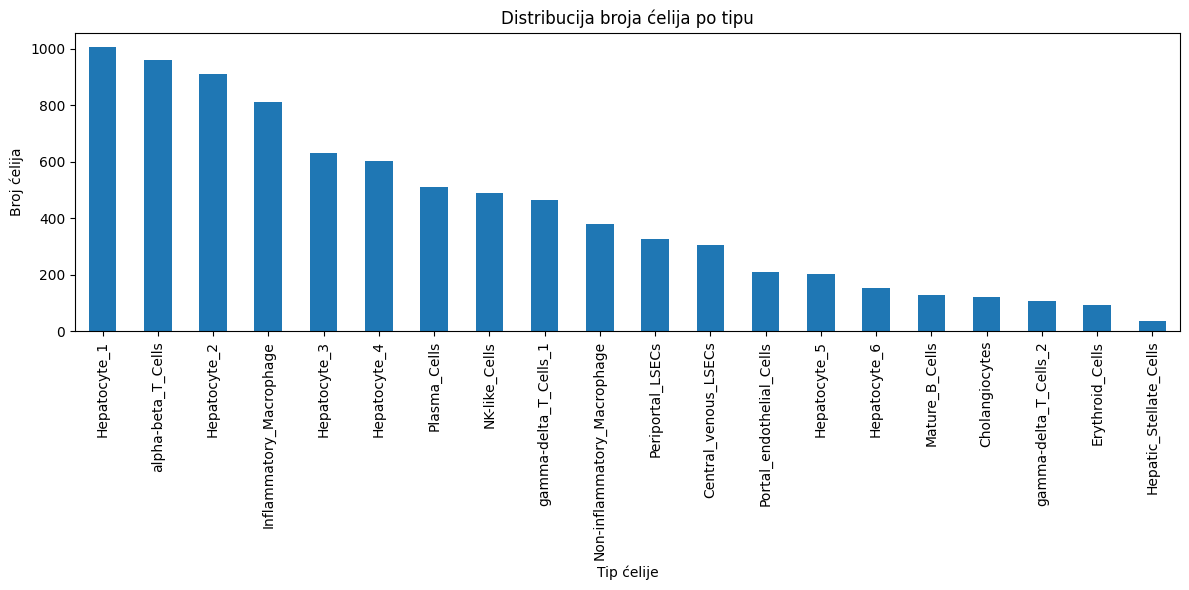

In [67]:
import matplotlib.pyplot as plt

cell_counts = pd.Series(y).value_counts()

plt.figure(figsize=(12,6))
cell_counts.plot(kind="bar")

plt.title('Distribucija broja ćelija po tipu')
plt.xlabel('Tip ćelije')
plt.ylabel('Broj ćelija')

plt.xticks(rotation=90)
plt.tight_layout()
plt.show()

Pre treniranja klasifikacionih modela analizirana je distribucija klasa, odnosno zastupljenost različitih tipova ćelija u skupu podataka. Ova analiza je važna jer neuravnoteženost klasa može uticati na performanse klasifikacionih algoritama, posebno na sposobnost modela da pravilno prepozna manje zastupljene ćelijske populacije.

Na osnovu prikazane distribucije može se uočiti da skup podataka nije potpuno uniforman, odnosno da pojedini tipovi ćelija sadrže veći broj uzoraka u odnosu na druge. Najzastupljenije su hepatocitne populacije, što je očekivano s obzirom na to da hepatociti predstavljaju dominantan tip ćelija u ljudskoj jetri. Sa druge strane, pojedine klase imaju manji broj dostupnih uzoraka.

Iako postoji određena razlika u broju uzoraka između klasa, sve klase sadrže dovoljan broj primera za treniranje modela. Zbog toga nije bilo potrebno uklanjanje klasa ili dodatno balansiranje skupa podataka. Prilikom evaluacije modela korišćene su macro metrike (Macro Precision, Macro Recall i Macro F1-score), kako bi se obezbedilo da performanse na manje zastupljenim klasama imaju jednak značaj kao i performanse na dominantnim klasama.

## Korak 3: Kodiranje target promenljive
Atribut CellType predstavlja kategorijsku promenljivu, odnosno sadrži tekstualne oznake različitih tipova ćelija (na primer, različite populacije ćelija prisutne u ljudskoj jetri). Pošto većina algoritama mašinskog učenja zahteva numeričku reprezentaciju ciljnih klasa, izvršeno je kodiranje ciljne promenljive.

Za kodiranje je korišćena metoda **Label Encoding**, kojom je svakoj jedinstvenoj vrednosti atributa CellType dodeljena odgovarajuća numerička oznaka. Na primer, različiti tipovi ćelija su transformisani u celobrojne vrednosti (0, 1, 2, ...), pri čemu svaka oznaka jednoznačno odgovara jednoj klasi. Kodiranje je primenjeno isključivo na ciljnu promenljivu, dok su ulazni atributi ostali u obliku numeričkih vrednosti ekspresije gena.

Prilikom interpretacije rezultata numeričke oznake klasa mogu se ponovo mapirati na originalne nazive tipova ćelija korišćenjem sačuvanog enkodera.

In [88]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()
y = le.fit_transform(y)

In [37]:
mapping = pd.DataFrame({
    'CellType': le.classes_,
    'EncodedValue': le.transform(le.classes_)
})

mapping

,CellType,EncodedValue
0,Central_venous_LSECs,0
1,Cholangiocytes,1
2,Erythroid_Cells,2
3,Hepatic_Stellate_Cells,3
4,Hepatocyte_1,4
5,Hepatocyte_2,5
6,Hepatocyte_3,6
7,Hepatocyte_4,7
8,Hepatocyte_5,8
9,Hepatocyte_6,9


## Korak 4: Podela podataka na trening i test skup

Nakon definisanja ulaznih atributa i ciljne promenljive izvršena je podela skupa podataka na trening i test skup.

Podaci su podeljeni na:

- **trening skup** – koristi se za treniranje klasifikacionih modela i učenje veza između ekspresije gena i tipa ćelije  
- **test skup** – koristi se za procenu sposobnosti modela da generalizuje naučene obrasce na nove, neviđene ćelije

Prilikom podele korišćen je odnos 80:20, gde je 80% podataka iskorišćeno za trening, a 20% za testiranje modela.

Kako bi se očuvala zastupljenost svih tipova ćelija u oba skupa, primenjena je **stratifikovana podela** prema ciljnoj promenljivoj CellType. Na ovaj način je obezbeđeno da raspodela klasa u trening i test skupu bude približno ista kao u originalnom skupu podataka.

Za reproduktivnost rezultata korišćen je fiksiran slučajni parametar (random_state), čime se obezbeđuje da se ista podela podataka dobije prilikom svakog pokretanja algoritma.

In [20]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    stratify=y,
    random_state=42
)

## Korak 5: Standardizacija ulaznih atributa

Nakon podele podataka na trening i test skup izvršena je standardizacija ulaznih atributa za modele koji su osetljivi na skalu podataka (**Support Vector Machine** i **Logistic Regression**).

Podaci o ekspresiji gena mogu imati različite opsege vrednosti, zbog čega atributi sa većim numeričkim vrednostima mogu imati veći uticaj na model. Standardizacijom se svi atributi transformišu tako da imaju približno srednju vrednost 0 i standardnu devijaciju 1.

Standardizacija je sprovedena primenom metode **StandardScaler**. Parametri potrebni za transformaciju izračunati su isključivo na trening skupu podataka, nakon čega je ista transformacija primenjena i na test skup. Ovakav pristup omogućava pravilnu evaluaciju modela i sprečava prenos informacija iz test skupa u fazu treniranja.

Modeli kojima je primenjena standardizacija:

- Support Vector Machine (SVM)
- Logistic Regression

Modeli zasnovani na stablima:

- Random Forest
- Gradient Boosting
- XGBoost

nisu zahtevali standardizaciju, jer se njihove odluke zasnivaju na podelama po vrednostima atributa, a ne na rastojanjima između podataka.

In [21]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

## Opciono: Feature Selection

Postoji mnogo više gena nego ćelija, biramo podskup najinformativnijih gena.

Ovo ostaviti kao opciju za istrazivanje

In [ ]:
from sklearn.feature_selection import SelectKBest, f_classif

selector = SelectKBest(
    score_func=f_classif,
    k=500
)

X_selected = selector.fit_transform(X_scaled, y)

NameError: name 'X_scaled' is not defined

# Klasifikacioni modeli

Nakon završene obrade podataka primenjeni su različiti klasifikacioni algoritmi sa ciljem predviđanja tipa ćelije (*CellType*) na osnovu obrazaca genske ekspresije dobijenih single-cell RNA-seq metodom.

Korišćeni su sledeći modeli:

* **Random Forest**
* **Gradient Boosting**
* **XGBoost**
* **Support Vector Machine (SVM)**
* **Logistic Regression**

Prva tri modela pripadaju metodama zasnovanim na stablima odlučivanja, dok SVM i Logistic Regression predstavljaju modele koji se zasnivaju na pronalaženju granica između klasa u prostoru atributa.

Izbor više različitih algoritama omogućava procenu koji pristup najuspešnije prepoznaje različite tipove ćelija na osnovu njihovih profila ekspresije gena. Ovo je posebno značajno kod single-cell RNA-seq podataka, gde postoji veliki broj atributa (gena), kompleksni obrasci ekspresije i potencijalno nelinearne razlike između ćelijskih populacija.

Performanse svakog modela ocenjene su korišćenjem odgovarajućih metrika klasifikacije, nakon čega je izvršeno poređenje dobijenih rezultata.

# Rezultati modela

Nakon treniranja svakog klasifikatora izvršena je evaluacija modela na test skupu podataka. Cilj evaluacije bio je da se proceni uspešnost modela u predviđanju tipova ćelija na osnovu profila genske ekspresije.

Za evaluaciju performansi modela korišćene su sledeće metrike:

* **Accuracy** – procenat ispravno klasifikovanih ćelija  
* **Precision** – mera tačnosti predikcija za svaku klasu  
* **Recall** – sposobnost modela da prepozna pripadnike određene klase  
* **Macro F1-score** – harmonijska sredina preciznosti i odziva, izračunata kao prosečna vrednost preko svih klasa

Korišćena je *macro* varijanta metrika kako bi sve klase imale jednaku težinu prilikom evaluacije, bez obzira na broj ćelija koje sadrže.

Radi detaljnije analize rezultata prikazan je i izveštaj klasifikacije (*classification report*), kao i matrica konfuzije (*confusion matrix*), koja omogućava uvid u to koje tipove ćelija model najčešće međusobno meša.

Dobijeni rezultati ukazuju na sposobnost algoritma da prepozna obrasce genske ekspresije karakteristične za različite tipove ćelija ljudske jetre.

In [68]:
from sklearn.metrics import accuracy_score, f1_score, recall_score, precision_score, classification_report, ConfusionMatrixDisplay
import matplotlib.pyplot as plt


def evaluate_model(model_name, pred):
    accuracy = accuracy_score(y_test, pred)
    precision = precision_score(y_test, pred, average="macro")
    recall = recall_score(y_test, pred, average="macro")
    f1 = f1_score(y_test, pred, average="macro")
    
    print(f"===== {model_name} =====")
    print(f"Accuracy: {accuracy:.4f}")
    print(f"Precision: {precision:.4f}")
    print(f"Recall: {recall:.4f}")
    print(f"Macro F1-score: {f1:.4f}")
    
    print("\nClassification Report:")
    print(
        classification_report(
            y_test,
            pred,
            target_names=le.classes_
        )
    )
    
    plt.figure(figsize=(12, 10))
    
    ConfusionMatrixDisplay.from_predictions(
        y_test,
        pred,
        display_labels=le.classes_,
        cmap="Blues",
        xticks_rotation=90
    )
    
    plt.title(f"Confusion Matrix - {model_name}")
    plt.show()
    
    return accuracy, precision, recall, f1

## Random Forest

Random Forest predstavlja ensemble klasifikacioni algoritam zasnovan na kombinaciji većeg broja stabala odlučivanja (*decision trees*). Umesto korišćenja samo jednog stabla, Random Forest formira veliki broj nezavisnih stabala koja se treniraju na različitim podskupovima podataka i atributa. Konačna odluka o klasi donosi se glasanjem svih pojedinačnih stabala, pri čemu se za klasifikaciju bira klasa sa najvećim brojem glasova.

Glavna prednost ovog pristupa je smanjenje preprilagođavanja (*overfitting*) u odnosu na pojedinačna stabla odlučivanja, kao i sposobnost modela da pronađe kompleksne i nelinearne odnose između ulaznih atributa i ciljne promenljive.

U ovom projektu Random Forest je primenjen za klasifikaciju tipova ćelija na osnovu vrednosti ekspresije gena. Ovaj algoritam je posebno pogodan za single-cell RNA-seq podatke jer može efikasno da radi sa velikim brojem atributa i nije zahtevan u pogledu pretprocesiranja podataka. Za razliku od modela koji se zasnivaju na rastojanju između podataka, Random Forest ne zahteva standardizaciju ulaznih atributa.

Za treniranje modela korišćeni su sledeći parametri:

* **n_estimators = 200** – broj stabala odlučivanja koja čine ansambl  
* **random_state = 42** – omogućava reproduktivnost rezultata  
* **n_jobs = -1** – omogućava korišćenje svih dostupnih procesorskih jezgara radi ubrzanja treniranja

Nakon treniranja modela na trening skupu, izvršeno je predviđanje tipova ćelija na test skupu, a performanse modela ocenjene su pomoću metrika klasifikacije.

In [26]:
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(
    n_estimators=200,
    random_state=42,
    n_jobs=-1
)

rf.fit(X_train, y_train)

pred_rf = rf.predict(X_test)

===== Random Forest =====
Accuracy: 0.9313
Precision: 0.9522
Recall: 0.8873
Macro F1-score: 0.9099

Classification Report:
                             precision    recall  f1-score   support

       Central_venous_LSECs       0.94      0.97      0.95        61
             Cholangiocytes       0.96      1.00      0.98        24
            Erythroid_Cells       1.00      0.95      0.97        19
     Hepatic_Stellate_Cells       1.00      0.43      0.60         7
               Hepatocyte_1       0.88      0.91      0.89       201
               Hepatocyte_2       0.91      0.91      0.91       182
               Hepatocyte_3       0.95      1.00      0.98       126
               Hepatocyte_4       0.87      0.90      0.89       121
               Hepatocyte_5       1.00      0.85      0.92        40
               Hepatocyte_6       0.90      0.63      0.75        30
    Inflammatory_Macrophage       0.95      0.98      0.96       163
             Mature_B_Cells       1.00      1.00

<Figure size 1200x1000 with 0 Axes>

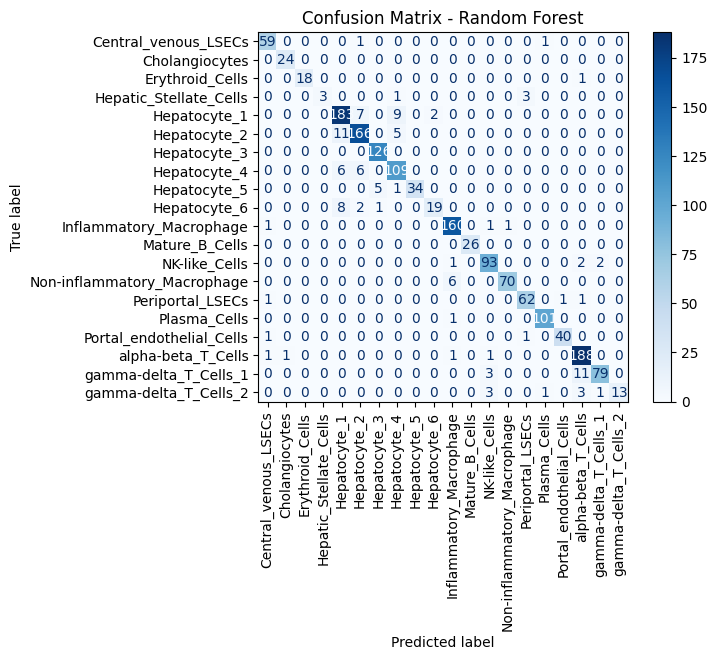

In [69]:
rf_accuracy, rf_precision, rf_recall, rf_f1 = evaluate_model('Random Forest', pred_rf)

Random Forest klasifikator ostvario je visoku uspešnost na test skupu podataka. Dobijene vrednosti evaluacionih metrika iznosile su:

* **Accuracy:** 93.13%
* **Macro Recall:** 88.73%
* **Macro F1-score:** 90.99%

Visoka vrednost tačnosti ukazuje da je model uspešno klasifikovao najveći deo ćelija u odgovarajuće tipove. Pored toga, Macro F1-score veći od 0.90 pokazuje da model postiže dobar balans između preciznosti i odziva kroz različite klase.

Analizom pojedinačnih klasa uočava se da je model za većinu tipova ćelija ostvario veoma visoke vrednosti preciznosti i odziva. Sa druge strane, kod pojedinih manje zastupljenih klasa primećene su niže vrednosti odziva. Na primer, klasa *Hepatic_Stellate_Cells* ostvarila je odziv od 0.43, dok je za klasu *gamma-delta_T_Cells_2* odziv iznosio 0.62. Ovakvo ponašanje može se objasniti manjim brojem dostupnih primera za treniranje, što otežava modelu da nauči karakteristične obrasce ekspresije za te klase.

Razlika između ukupne tačnosti (93.13%) i Macro Recall vrednosti (88.73%) ukazuje da model postiže nešto bolje rezultate na brojnijim klasama nego na retkim klasama. Ipak, ostvareni rezultati pokazuju da je Random Forest veoma efikasan za klasifikaciju tipova ćelija na osnovu podataka o genskoj ekspresiji.

Na osnovu dobijenih metrika može se zaključiti da Random Forest uspešno prepoznaje obrasce karakteristične za različite ćelijske populacije i predstavlja snažan osnovni model za analizu single-cell RNA-seq podataka.

## Gradient Boosting

Gradient Boosting predstavlja ensemble algoritam zasnovan na kombinaciji više slabijih modela, najčešće stabala odlučivanja (*decision trees*), koji se grade sekvencijalno. Za razliku od Random Forest algoritma, gde se stabla treniraju nezavisno i njihova predviđanja se kombinuju glasanjem, kod Gradient Boosting pristupa svako novo stablo pokušava da ispravi greške prethodno izgrađenih stabala.

Princip rada algoritma zasniva se na iterativnom poboljšavanju modela. Prvo se formira početni model, nakon čega se analiziraju greške u njegovim predikcijama. Naredna stabla se zatim treniraju tako da smanje prethodno napravljene greške. Na ovaj način se postepeno gradi snažan klasifikator koji može da nauči složene obrasce u podacima.

U ovom projektu Gradient Boosting je korišćen za klasifikaciju tipova ćelija na osnovu ekspresije gena dobijene single-cell RNA-seq metodom. Ovaj algoritam je pogodan za ovakav tip problema jer može da modeluje nelinearne odnose između gena i različitih ćelijskih populacija, kao i interakcije između većeg broja atributa.

Za razliku od algoritama koji se zasnivaju na merenju udaljenosti između podataka, Gradient Boosting ne zahteva standardizaciju ulaznih atributa. Zbog toga je model treniran na originalnim vrednostima genske ekspresije nakon prethodno izvršenog odabira atributa i podele podataka na trening i test skup.

Za treniranje modela korišćeni su sledeći parametri:

* **n_estimators = 100** – broj stabala koja se grade sekvencijalno;
* **learning_rate = 0.1** – određuje doprinos svakog pojedinačnog stabla konačnom modelu;
* **random_state = 42** – omogućava reproduktivnost rezultata.

Nakon treniranja modela izvršeno je predviđanje tipova ćelija na test skupu, a performanse su ocenjene korišćenjem metrika klasifikacije: accuracy, precision, recall i F1-score. Rezultati su dodatno analizirani pomoću klasifikacionog izveštaja i matrice konfuzije.

In [27]:
from sklearn.ensemble import GradientBoostingClassifier

gb = GradientBoostingClassifier(
    random_state=42
)

gb.fit(X_train, y_train)

pred_gb = gb.predict(X_test)

===== Gradient Boost =====
Accuracy: 0.9485
Precision: 0.9541
Recall: 0.9476
Macro F1-score: 0.9505

Classification Report:
                             precision    recall  f1-score   support

       Central_venous_LSECs       0.94      0.98      0.96        61
             Cholangiocytes       1.00      1.00      1.00        24
            Erythroid_Cells       1.00      1.00      1.00        19
     Hepatic_Stellate_Cells       1.00      1.00      1.00         7
               Hepatocyte_1       0.91      0.91      0.91       201
               Hepatocyte_2       0.94      0.92      0.93       182
               Hepatocyte_3       1.00      1.00      1.00       126
               Hepatocyte_4       0.89      0.94      0.92       121
               Hepatocyte_5       1.00      0.97      0.99        40
               Hepatocyte_6       0.85      0.73      0.79        30
    Inflammatory_Macrophage       0.96      0.97      0.96       163
             Mature_B_Cells       1.00      1.0

<Figure size 1200x1000 with 0 Axes>

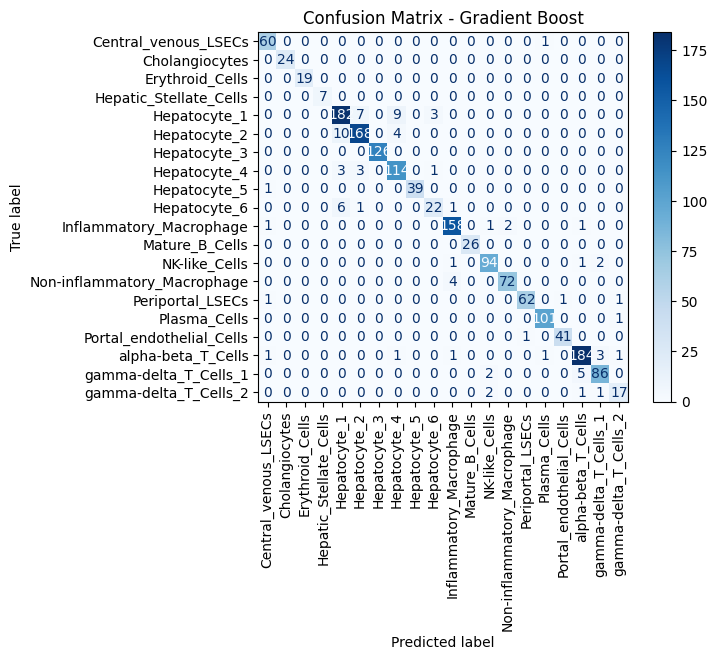

In [70]:
gb_accuracy, gb_precision, gb_recall, gb_f1 = evaluate_model('Gradient Boost', pred_gb)

Gradient Boosting klasifikator ostvario je veoma visoke performanse u klasifikaciji tipova ćelija na osnovu genske ekspresije. Evaluacijom na test skupu dobijene su sledeće vrednosti metrika:

* **Accuracy:** 94.85%
* **Precision:** 95.41%
* **Macro Recall:** 94.76%
* **Macro F1-score:** 95.05%

Visoka vrednost svih korišćenih metrika pokazuje da je model uspešno naučio obrasce genske ekspresije karakteristične za različite tipove ćelija. Posebno je značajno što su vrednosti macro proseka približne ukupnoj tačnosti, što ukazuje da model postiže dobre rezultate ne samo na najzastupljenijim klasama, već i na klasama sa manjim brojem uzoraka.

Analizom pojedinačnih klasa primećuje se da je Gradient Boosting za veliki broj tipova ćelija ostvario gotovo savršenu klasifikaciju. Klase kao što su **Cholangiocytes**, **Erythroid_Cells**, **Hepatic_Stellate_Cells**, **Hepatocyte_3** i **Mature_B_Cells** klasifikovane su bez greške, sa F1 skorom jednakim 1.00.

Nešto slabiji rezultati primećeni su kod klase **Hepatocyte_6**, gde je odziv iznosio 0.73, što ukazuje na to da model deo ćelija ove klase pogrešno svrstava u druge kategorije. Mogući razlog za ovakvo ponašanje jeste manji broj dostupnih primera ove klase u test skupu, kao i veća sličnost profila genske ekspresije sa drugim podtipovima hepatocita.

U poređenju sa Random Forest modelom, Gradient Boosting je ostvario bolje rezultate, sa većom tačnošću i većim Macro F1 skorom. Ovo ukazuje da sekvencijalno učenje stabala i postepeno ispravljanje grešaka omogućavaju modelu da bolje uhvati kompleksne obrasce prisutne u single-cell RNA-seq podacima.


## XGBoost

XGBoost (*Extreme Gradient Boosting*) predstavlja unapređenu verziju Gradient Boosting algoritma koja je zasnovana na sekvencijalnom građenju stabala odlučivanja. Kao i kod standardnog Gradient Boosting pristupa, svaki novi model pokušava da ispravi greške prethodno izgrađenih modela, čime se postepeno poboljšava konačna klasifikacija.

Glavna razlika u odnosu na klasični Gradient Boosting jeste u dodatnim tehnikama regularizacije i optimizacije koje XGBoost koristi kako bi smanjio rizik od preprilagođavanja (*overfitting*) i poboljšao generalizaciju modela. Algoritam uvodi regularizacione članove u funkciju greške, podršku za paralelnu obradu i efikasnije upravljanje velikim skupovima podataka.

Kao i ostali algoritmi zasnovani na stablima odlučivanja, XGBoost ne zahteva standardizaciju ulaznih atributa, pa je treniran na originalnim vrednostima genske ekspresije nakon izvršenog odabira atributa i podele podataka na trening i test skup.

Za treniranje modela korišćeni su sledeći parametri:

* **n_estimators = 200** – broj stabala u ansamblu;
* **learning_rate = 0.1** – brzina kojom pojedinačna stabla doprinose konačnom modelu;
* **max_depth = 6** – maksimalna dubina pojedinačnih stabala;
* **random_state = 42** – omogućava reproduktivnost rezultata.

Nakon treniranja modela izvršeno je predviđanje tipova ćelija na test skupu. 

In [28]:
from xgboost import XGBClassifier

xgb = XGBClassifier(
    n_estimators=200,
    max_depth=6,
    learning_rate=0.1,
    random_state=42
)

xgb.fit(X_train, y_train)

pred_xgb = xgb.predict(X_test)

===== XGBoost =====
Accuracy: 0.9491
Precision: 0.9545
Recall: 0.9370
Macro F1-score: 0.9438

Classification Report:
                             precision    recall  f1-score   support

       Central_venous_LSECs       0.92      0.97      0.94        61
             Cholangiocytes       1.00      1.00      1.00        24
            Erythroid_Cells       0.95      1.00      0.97        19
     Hepatic_Stellate_Cells       1.00      0.71      0.83         7
               Hepatocyte_1       0.91      0.89      0.90       201
               Hepatocyte_2       0.93      0.93      0.93       182
               Hepatocyte_3       1.00      1.00      1.00       126
               Hepatocyte_4       0.86      0.93      0.90       121
               Hepatocyte_5       1.00      0.95      0.97        40
               Hepatocyte_6       0.92      0.77      0.84        30
    Inflammatory_Macrophage       0.95      0.98      0.97       163
             Mature_B_Cells       1.00      0.96      

<Figure size 1200x1000 with 0 Axes>

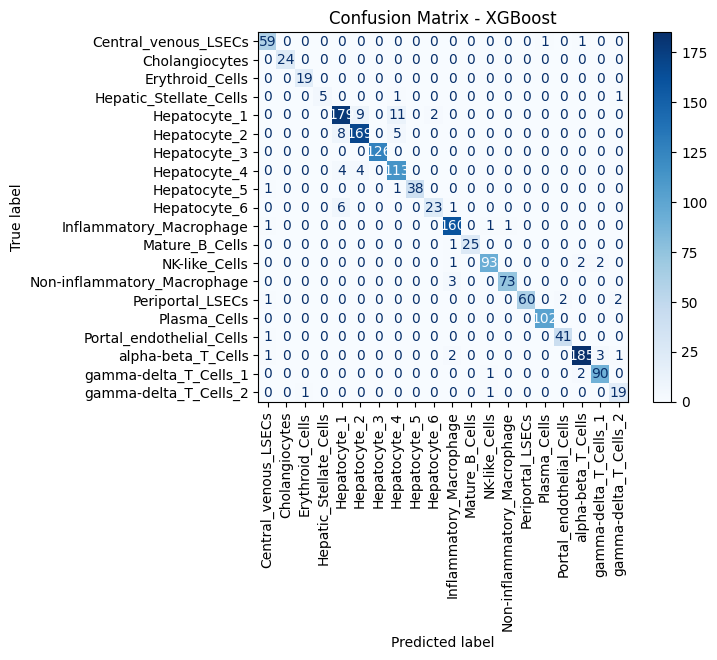

In [71]:
xgb_accuracy, xgb_precision, xgb_recall, xgb_f1 = evaluate_model('XGBoost', pred_xgb)

XGBoost klasifikator ostvario je veoma visoke performanse u klasifikaciji tipova ćelija na osnovu profila genske ekspresije. Na test skupu dobijene su sledeće vrednosti evaluacionih metrika:

* **Accuracy:** 94.91%
* **Precision:** 95.45%
* **Macro Recall:** 93.70%
* **Macro F1-score:** 94.38%

Visoka vrednost tačnosti pokazuje da je XGBoost uspešno klasifikovao najveći broj ćelija u odgovarajuće kategorije. Takođe, visoke vrednosti precision i F1-score metrike ukazuju da model uspešno razlikuje različite tipove ćelija na osnovu njihovih obrazaca genske ekspresije.

Analizom pojedinačnih klasa uočava se da je model za veliki broj ćelijskih tipova ostvario veoma dobre rezultate. Klase **Cholangiocytes** i **Hepatocyte_3** klasifikovane su potpuno precizno, sa F1 skorom 1.00. Takođe, visoke vrednosti F1 skora ostvarene su kod većine imunskih ćelijskih populacija, kao što su **Inflammatory_Macrophage**, **Non-inflammatory_Macrophage**, **NK-like_Cells** i **Plasma_Cells**.

Najveće poteškoće model je imao kod klasa sa manjim brojem uzoraka. Kod klase **Hepatic_Stellate_Cells** odziv je iznosio 0.71, dok je kod klase **Hepatocyte_6** odziv iznosio 0.77. Ovo ukazuje da model deo ćelija ovih klasa pogrešno klasifikuje, što može biti posledica manjeg broja dostupnih primera ili sličnosti njihovih profila genske ekspresije sa drugim ćelijskim tipovima.

U poređenju sa Gradient Boosting algoritmom, XGBoost je ostvario nešto veću ukupnu tačnost (94.91% u odnosu na 94.85%), ali nešto niži Macro F1-score (94.38% u odnosu na 95.05%). Ovo ukazuje da XGBoost veoma uspešno klasifikuje ukupno posmatrane ćelije, dok Gradient Boosting ostvaruje nešto ujednačenije performanse kroz sve klase.

Dobijeni rezultati potvrđuju da je XGBoost pogodan algoritam za klasifikaciju single-cell RNA-seq podataka, jer je sposoban da modeluje kompleksne nelinearne odnose između ekspresije gena i pripadnosti određenom tipu ćelije.


## Logistička regresija

Logistička regresija predstavlja jedan od najčešće korišćenih algoritama za klasifikaciju i koristi se za predviđanje pripadnosti uzorka određenoj klasi na osnovu ulaznih atributa. Iako u nazivu sadrži reč „regresija”, ovaj algoritam se koristi za klasifikacione probleme tako što modeluje verovatnoću pripadnosti različitim klasama.

U slučaju višeklasne klasifikacije, kakva je prisutna u ovom projektu, koristi se pristup **multinomial logistic regression**, gde model istovremeno procenjuje verovatnoće pripadnosti svim dostupnim klasama i bira onu klasu sa najvećom verovatnoćom.

Za razliku od algoritama zasnovanih na stablima odlučivanja, logistička regresija zahteva skaliranje ulaznih atributa, jer se prilikom optimizacije koriste vrednosti atributa i njihove međusobne razmere mogu uticati na proces učenja. Zbog toga je pre treniranja modela primenjena standardizacija atributa korišćenjem **StandardScaler** metode.

Za treniranje modela korišćeni su sledeći parametri:

* **max_iter = 1000** – maksimalan broj iteracija optimizacionog algoritma;
* **solver = "lbfgs"** – optimizacioni algoritam korišćen za pronalaženje optimalnih parametara modela;
* **random_state = 42** – omogućava reproduktivnost rezultata.

Nakon treniranja modela izvršeno je predviđanje tipova ćelija na test skupu. Performanse su ocenjene pomoću accuracy, precision, recall i F1-score metrika, dok su dodatna analiza grešaka i ponašanja po klasama izvršene korišćenjem classification report-a i matrice konfuzije.


In [29]:
from sklearn.linear_model import LogisticRegression

lr = LogisticRegression(
    max_iter=1000,
    random_state=42
)

lr.fit(X_train_scaled, y_train)

pred_lr = lr.predict(X_test_scaled)

===== Logistic Regression =====
Accuracy: 0.9497
Precision: 0.9589
Recall: 0.9428
Macro F1-score: 0.9492

Classification Report:
                             precision    recall  f1-score   support

       Central_venous_LSECs       0.95      0.98      0.97        61
             Cholangiocytes       1.00      1.00      1.00        24
            Erythroid_Cells       0.95      0.95      0.95        19
     Hepatic_Stellate_Cells       1.00      0.86      0.92         7
               Hepatocyte_1       0.89      0.90      0.89       201
               Hepatocyte_2       0.91      0.95      0.93       182
               Hepatocyte_3       1.00      1.00      1.00       126
               Hepatocyte_4       0.89      0.90      0.90       121
               Hepatocyte_5       0.98      1.00      0.99        40
               Hepatocyte_6       0.95      0.67      0.78        30
    Inflammatory_Macrophage       0.96      0.97      0.97       163
             Mature_B_Cells       1.00    

<Figure size 1200x1000 with 0 Axes>

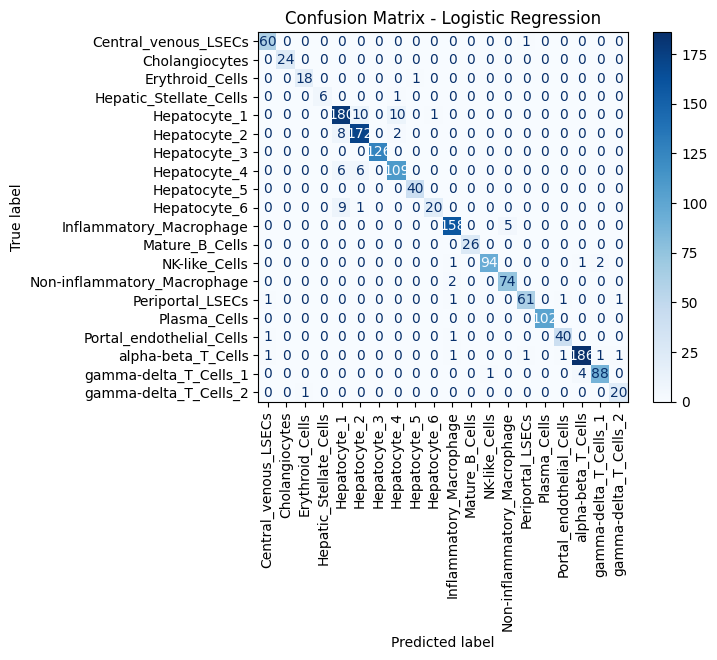

In [72]:
lr_accuracy, lr_precision, lr_recall, lr_f1 = evaluate_model('Logistic Regression', pred_lr)

## Rezultati Logistic Regression modela

Logistic Regression model ostvario je veoma visoke performanse u klasifikaciji tipova ćelija na osnovu genske ekspresije. Evaluacijom na test skupu dobijene su sledeće vrednosti:

* **Accuracy:** 94.97%
* **Precision:** 95.89%
* **Macro Recall:** 94.28%
* **Macro F1-score:** 94.92%

Dobijene vrednosti metrika pokazuju da je logistička regresija uspešno naučila vezu između obrazaca genske ekspresije i pripadajućih tipova ćelija. Iako predstavlja jednostavniji model u odnosu na ensemble metode zasnovane na stablima odlučivanja, ostvario je veoma konkurentne rezultate.

Analizom rezultata po klasama uočava se da je model veliki broj ćelijskih tipova klasifikovao sa veoma visokom uspešnošću. Klase **Cholangiocytes**, **Hepatocyte_3**, **Mature_B_Cells** i **Plasma_Cells** ostvarile su savršenu klasifikaciju, sa F1 skorom 1.00. Takođe, većina ostalih klasa ostvarila je F1 vrednosti veće od 0.90.

Najveći izazov za model predstavljala je klasa **Hepatocyte_6**, kod koje je odziv iznosio 0.67. Ovo ukazuje da je određeni broj ćelija ove klase pogrešno klasifikovan u druge kategorije, što može biti posledica manjeg broja uzoraka ove klase ili sličnosti u profilima genske ekspresije između različitih podtipova hepatocita.

U poređenju sa prethodno korišćenim modelima, Logistic Regression je ostvarila najbolju ukupnu tačnost do sada (94.97%). Rezultat je posebno značajan jer je dobijen korišćenjem linearnog modela, što ukazuje da su različiti tipovi ćelija u prostoru genske ekspresije relativno dobro razdvojivi.

Iako složeniji modeli poput Gradient Boosting i XGBoost mogu bolje da modeluju nelinearne odnose, logistička regresija je pokazala da i jednostavniji klasifikacioni pristup može postići veoma visoku preciznost na single-cell RNA-seq podacima.


## Support Vector Machine (SVM)

Support Vector Machine (SVM) predstavlja nadgledani algoritam mašinskog učenja koji se koristi za klasifikaciju podataka pronalaženjem optimalne granice razdvajanja između različitih klasa. Osnovna ideja algoritma jeste pronalaženje hiperravni koja maksimalizuje marginu između najbližih uzoraka različitih klasa, čime se postiže dobra sposobnost generalizacije na novim podacima.

U slučaju kada podaci nisu linearno razdvojivi, SVM može koristiti kernel funkcije koje omogućavaju preslikavanje podataka u prostor veće dimenzionalnosti, gde je moguće pronaći odgovarajuću granicu razdvajanja. U ovom projektu korišćen je **Radial Basis Function (RBF) kernel**, koji omogućava modelovanje složenih i nelinearnih odnosa između obrazaca genske ekspresije i tipova ćelija.

SVM je primenjen za klasifikaciju tipova ćelija ljudske jetre na osnovu podataka dobijenih single-cell RNA-seq metodom. Ovaj algoritam je posebno pogodan za visokodimenzionalne skupove podataka, kakav je korišćeni skup gde svaki uzorak predstavlja ćeliju opisanu velikim brojem atributa koji odgovaraju nivoima ekspresije gena.

Za razliku od algoritama zasnovanih na stablima odlučivanja, SVM je osetljiv na skalu atributa, zbog čega je pre treniranja izvršena standardizacija ulaznih atributa korišćenjem **StandardScaler** metode. Standardizacija omogućava da svi geni imaju uporediv uticaj tokom procesa učenja.

Za treniranje modela korišćeni su sledeći parametri:

* **kernel = "rbf"** – omogućava modelovanje nelinearnih odnosa između klasa;
* **C = 1** – parametar regularizacije koji kontroliše kompromis između širine margine i broja grešaka klasifikacije;
* **gamma = "scale"** – određuje uticaj pojedinačnih trening primera na granicu odlučivanja;
* **random_state = 42** – omogućava reproduktivnost rezultata.

Nakon treniranja modela izvršeno je predviđanje tipova ćelija na test skupu. Performanse SVM modela ocenjene su korišćenjem accuracy, precision, recall i F1-score metrika, dok su dodatno analizirani classification report i matrica konfuzije.


In [ ]:
from sklearn.svm import SVC

svm = SVC(
    kernel="rbf",
    random_state=42
)

svm.fit(X_train_scaled, y_train)

pred_svm = svm.predict(X_test_scaled)

===== SVC =====
Accuracy: 0.9201
Precision: 0.9494
Recall: 0.8949
Macro F1-score: 0.9144

Classification Report:
                             precision    recall  f1-score   support

       Central_venous_LSECs       0.97      0.97      0.97        61
             Cholangiocytes       1.00      1.00      1.00        24
            Erythroid_Cells       1.00      0.58      0.73        19
     Hepatic_Stellate_Cells       1.00      0.71      0.83         7
               Hepatocyte_1       0.87      0.89      0.88       201
               Hepatocyte_2       0.95      0.89      0.92       182
               Hepatocyte_3       0.70      1.00      0.82       126
               Hepatocyte_4       0.88      0.85      0.87       121
               Hepatocyte_5       1.00      0.88      0.93        40
               Hepatocyte_6       0.95      0.60      0.73        30
    Inflammatory_Macrophage       0.95      0.97      0.96       163
             Mature_B_Cells       0.96      1.00      0.98

<Figure size 1200x1000 with 0 Axes>

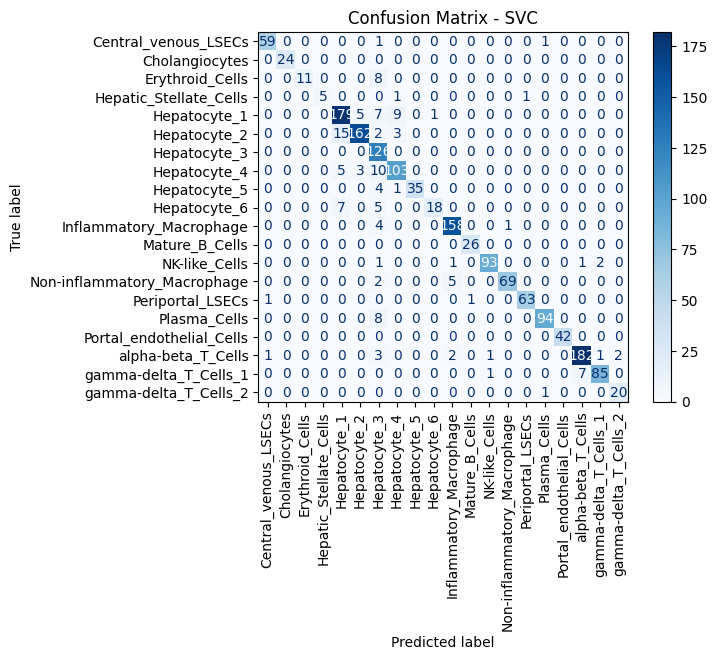

In [73]:
svc_accuracy, svc_precision, svc_recall, svc_f1 = evaluate_model('SVC', pred_svm)

SVM klasifikator ostvario je dobre performanse u klasifikaciji tipova ćelija na osnovu profila genske ekspresije. Evaluacijom modela na test skupu dobijene su sledeće vrednosti:

* **Accuracy:** 92.01%
* **Precision:** 94.94%
* **Macro Recall:** 89.49%
* **Macro F1-score:** 91.44%

Dobijeni rezultati pokazuju da SVM uspešno prepoznaje veliki broj obrazaca karakterističnih za različite tipove ćelija. Visoka vrednost precision metrike ukazuje da su predikcije modela uglavnom pouzdane, odnosno da kada model dodeli određeni tip ćelije, ta odluka je u velikom broju slučajeva ispravna.

Analizom pojedinačnih klasa primećuje se da je model ostvario odlične rezultate kod određenih ćelijskih populacija. Klase **Cholangiocytes** i **Mature_B_Cells** klasifikovane su sa veoma visokom uspešnošću, dok su kod većine ostalih klasa ostvarene F1 vrednosti iznad 0.90.

Najveći izazovi primećeni su kod klasa **Erythroid_Cells**, **Hepatocyte_6** i **Hepatocyte_3**. Kod klase **Erythroid_Cells** odziv je iznosio 0.58, što znači da model nije uspeo da prepozna značajan deo ćelija ove klase. Slično, kod klase **Hepatocyte_6** odziv je iznosio 0.60. Ovakvi rezultati mogu biti posledica sličnosti genske ekspresije između pojedinih podtipova ćelija, kao i manjeg broja dostupnih uzoraka za određene klase.

U poređenju sa ostalim korišćenim algoritmima, SVM je ostvario slabije rezultate od ensemble metoda i Logistic Regression modela. Razlog može biti složenost problema i veliki broj klasa, gde pronalaženje optimalnih granica razdvajanja između svih ćelijskih tipova postaje zahtevno.

Ipak, SVM je pokazao da je sposoban da izvrši uspešnu klasifikaciju visokodimenzionalnih single-cell RNA-seq podataka i predstavlja relevantan model za poređenje sa drugim klasifikacionim pristupima.

## Poređenje modela i zaključak

U okviru klasifikacije tipova ćelija ljudske jetre na osnovu single-cell RNA-seq podataka testirano je pet različitih algoritama mašinskog učenja: Random Forest, Gradient Boosting, XGBoost, Logistic Regression i Support Vector Machine (SVM).

Rezultati svih modela prikazani su u sledećoj tabeli:

| Model               |   Accuracy |  Precision | Macro Recall | Macro F1-score |
| ------------------- | ---------: | ---------: | -----------: | -------------: |
| Random Forest       |     0.9313 |     0.9500 |       0.8873 |         0.9099 |
| Gradient Boosting   |     0.9485 |     0.9541 |       0.9476 |     **0.9505** |
| XGBoost             |     0.9491 |     0.9545 |       0.9370 |         0.9438 |
| Logistic Regression | **0.9497** | **0.9589** |       0.9428 |         0.9492 |
| SVM                 |     0.9201 |     0.9494 |       0.8949 |         0.9144 |

Na osnovu dobijenih rezultata može se zaključiti da su svi modeli uspešno izvršili klasifikaciju različitih tipova ćelija, pri čemu su svi ostvarili tačnost veću od 92%. Najslabije performanse ostvario je SVM model, dok su ostali modeli pokazali veoma slične i visoke rezultate.

Najveću ukupnu tačnost ostvario je **Logistic Regression model** sa vrednošću od 94.97%. Ovaj rezultat je posebno značajan jer je ostvaren korišćenjem relativno jednostavnog linearnog modela, što ukazuje da su obrasci genske ekspresije različitih tipova ćelija u velikoj meri međusobno razdvojivi.

Sa druge strane, **Gradient Boosting model** ostvario je najbolju vrednost Macro F1-score metrike (95.05%), što ukazuje na najbolji balans između preciznosti i odziva kroz različite klase. Zbog toga se Gradient Boosting može smatrati najrobustnijim modelom za ovaj problem, posebno imajući u vidu da se u klasifikaciji pojavljuju i manje zastupljene ćelijske populacije.

**XGBoost** je ostvario rezultate veoma bliske Gradient Boosting modelu, sa nešto većom tačnošću, ali nešto nižom Macro F1 vrednošću. Ovo pokazuje da dodatne optimizacije i regularizacija koje XGBoost koristi doprinose dobroj generalizaciji, ali u ovom konkretnom skupu podataka nisu dovele do značajnog poboljšanja u odnosu na klasični Gradient Boosting.

**Random Forest** je takođe ostvario dobre rezultate, ali nešto slabije u poređenju sa boosting metodama. Njegova tačnost od 93.13% pokazuje da je sposoban da prepozna osnovne obrasce u genskoj ekspresiji, ali sekvencijalni pristup učenja kod boosting algoritama omogućava bolje hvatanje složenih odnosa između gena i tipova ćelija.

Na osnovu ukupne analize može se zaključiti da su **Gradient Boosting i Logistic Regression najuspešniji modeli za klasifikaciju tipova ćelija u ovom skupu podataka**. Gradient Boosting pokazuje najbolju sposobnost balansirane klasifikacije svih klasa, dok Logistic Regression pruža najvišu ukupnu tačnost uz jednostavniju strukturu modela.

Dobijeni rezultati potvrđuju da se podaci o genskoj ekspresiji dobijeni single-cell RNA-seq metodom mogu uspešno koristiti za automatsku identifikaciju ćelijskih populacija pomoću metoda mašinskog učenja.

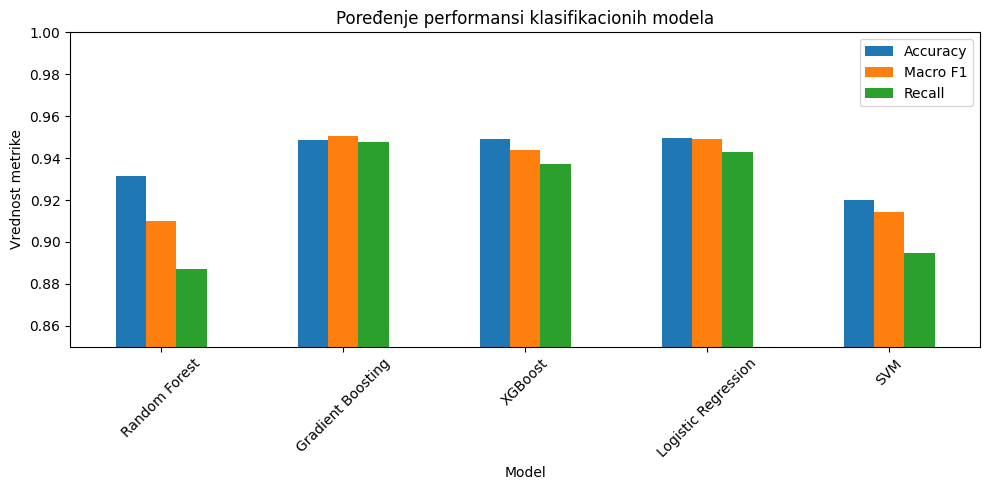

In [74]:
results = pd.DataFrame({
    'Model': [
        'Random Forest',
        'Gradient Boosting',
        'XGBoost',
        'Logistic Regression',
        'SVM'
    ],
    'Accuracy': [
        rf_accuracy,
        gb_accuracy,
        xgb_accuracy,
        lr_accuracy,
        svc_accuracy
    ],
    'Macro F1': [
        rf_f1,
        gb_f1,
        xgb_f1,
        lr_f1,
        svc_f1
    ],
    'Recall': [
        rf_recall,
        gb_recall,
        xgb_recall,
        lr_recall,
        svc_recall
    ]
})


results.plot(
    x='Model',
    y=['Accuracy','Macro F1','Recall'],
    kind='bar',
    figsize=(10,5)
)


plt.title('Poređenje performansi klasifikacionih modela')
plt.ylabel('Vrednost metrike')
plt.xlabel('Model')

plt.xticks(rotation=45)
plt.ylim(0.85,1)

plt.tight_layout()
plt.show()

### Analiza značajnosti gena

Jedna od prednosti algoritama zasnovanih na stablima odlučivanja (Random Forest, Gradient Boost i XGBoost) jeste mogućnost procene značajnosti ulaznih atributa (*feature importance*). U kontekstu ovog projekta, svaki atribut predstavlja jedan gen, pa se na ovaj način može analizirati koji geni imaju najveći doprinos u razlikovanju različitih tipova ćelija.

Tokom treniranja modela, izračunava se značajnost svakog gena na osnovu toga koliko često i koliko uspešno određeni atribut doprinosi podelama unutar stabala odlučivanja. Geni koji dovode do većeg smanjenja nečistoće čvorova (*impurity reduction*) dobijaju veće vrednosti značajnosti.

Nakon treniranja modela izdvojeni su geni sa najvećim vrednostima značajnosti. Ovi geni predstavljaju atribute koji su modelu bili najkorisniji za klasifikaciju tipova ćelija na osnovu njihovih profila ekspresije.

Analiza značajnosti gena pruža dodatni uvid u karakteristike skupa podataka, jer omogućava identifikaciju gena koji najviše doprinose razlikovanju ćelijskih populacija. Dobijeni rezultati mogu se dalje analizirati iz biološke perspektive, poređenjem sa poznatim markerima karakterističnim za određene tipove ćelija.


In [79]:
def calculate_importance(model):
    importance = pd.DataFrame({
        "Gene": X_train.columns,
        "Importance": model.feature_importances_
    }).sort_values("Importance", ascending=False)

    return importance.head(10)

In [80]:
calculate_importance(rf)

,Gene,Importance
933,CD3D,0.008836
611,MZB1,0.008727
300,FCER1G,0.007472
6,TTR,0.007463
374,LYZ,0.007368
89,TYROBP,0.006866
1105,TRAC,0.006653
8,APOA1,0.006566
23,APOH,0.006392
18,ORM2,0.006390


In [81]:
calculate_importance(gb)

,Gene,Importance
933,CD3D,0.079660
374,LYZ,0.075144
6,TTR,0.066751
611,MZB1,0.058947
248,SCD,0.056132
1142,MARCO,0.045335
1797,FGFBP2,0.039258
17,AMBP,0.038419
59,CES1,0.023731
1438,MGP,0.022928


In [83]:
calculate_importance(xgb)

,Gene,Importance
933,CD3D,0.036075
102,TAT-AS1,0.029046
611,MZB1,0.025881
374,LYZ,0.024110
6,TTR,0.023372
1241,FCN2,0.022952
1438,MGP,0.021009
248,SCD,0.020857
393,LINC00844,0.019577
46,HBB,0.014616


Rezultati pokazuju da se među najznačajnijim genima u više modela ponavljaju geni **CD3D**, **MZB1**, **LYZ** i **TTR**. Njihovo prisustvo u vrhu rang-lista kod različitih algoritama ukazuje da predstavljaju stabilne i informativne markere za razlikovanje ćelijskih populacija.

Gen CD3D zauzima prvo mesto kod sva tri modela, što ukazuje da ima najveću diskriminativnu moć u procesu klasifikacije. Ovaj gen je poznat kao marker T-limfocita, pa njegova visoka značajnost sugeriše da značajno doprinosi razlikovanju imunskih ćelijskih populacija od ostalih tipova ćelija.

Gen MZB1 se takođe nalazi među najvažnijim atributima kod sva tri modela. Poznato je da je povezan sa plazma ćelijama i B-limfocitima, što ukazuje da modeli uspešno prepoznaju obrasce genske ekspresije karakteristične za ove ćelijske tipove.

Gen LYZ predstavlja marker mijeloidnih ćelija i makrofaga, dok je TTR karakterističan za hepatocite. Njihova visoka značajnost potvrđuje da modeli koriste biološki relevantne obrasce ekspresije za razlikovanje ćelijskih populacija jetre.

Pored zajedničkih gena, pojedini modeli izdvajaju i specifične markere. Gradient Boosting i XGBoost ističu gene SCD, MGP i MARCO, dok XGBoost dodatno naglašava gene FCN2, TAT-AS1 i HBB. Ove razlike proizlaze iz različitog načina na koji algoritmi formiraju modele i procenjuju doprinos pojedinačnih atributa.

Ukupno posmatrano, visoko poklapanje najznačajnijih gena između modela ukazuje na robusnost rezultata i potvrđuje da su identifikovani geni ključni za razlikovanje tipova ćelija u skupu podataka dobijenom primenom single-cell RNA-seq metode.

### PCA

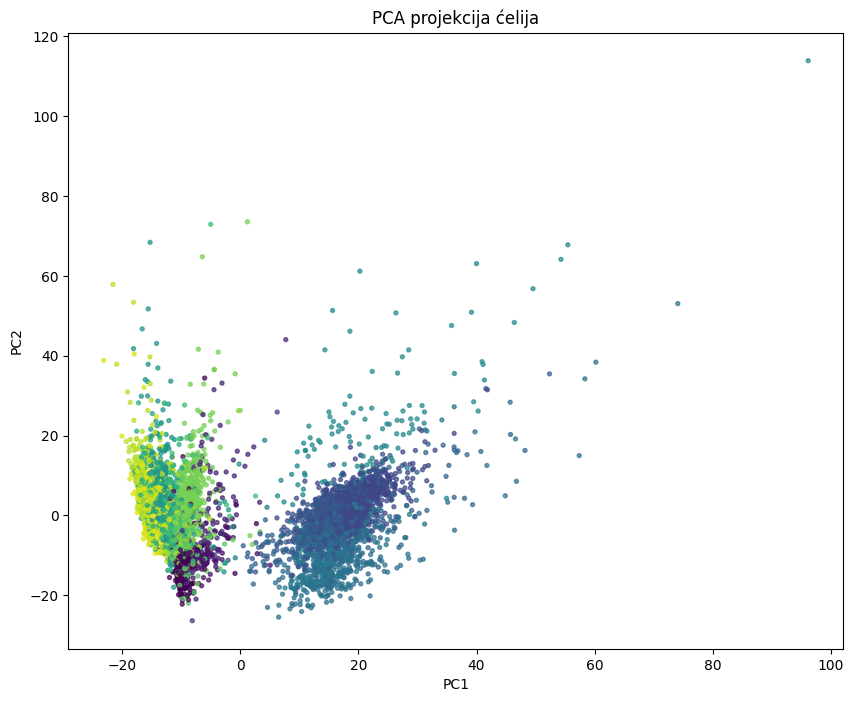

In [96]:
from sklearn.decomposition import PCA
pca = PCA(n_components=2)

X_pca = pca.fit_transform(X_train_scaled)

plt.figure(figsize=(10,8))

scatter = plt.scatter(
    X_pca[:,0],
    X_pca[:,1],
    c=y_train,
    s=8,
    alpha=0.7
)

plt.xlabel('PC1')
plt.ylabel('PC2')
plt.title('PCA projekcija ćelija')

plt.show()

U cilju vizualizacije visokodimenzionalnih podataka primenjena je analiza glavnih komponenti (PCA), kojom je prostor od 2000 genskih atributa projektovan na dve dimenzije. Na taj način omogućeno je grafičko prikazivanje međusobnih odnosa između ćelija.

Na prikazanoj projekciji mogu se uočiti formirane grupe ćelija, što ukazuje da ćelije različitih tipova poseduju karakteristične obrasce genske ekspresije. Istovremeno, prisutna su i područja delimičnog preklapanja grupa, što je očekivano zbog biološke srodnosti pojedinih ćelijskih populacija, posebno među različitim podtipovima hepatocita.

Dobijeni rezultat potvrđuje da podaci sadrže strukturu koja omogućava uspešnu klasifikaciju ćelijskih tipova, što je kasnije potvrđeno i visokim performansama klasifikacionih modela.

In [33]:
import joblib
import os

In [35]:
os.makedirs('models', exist_ok=True)

joblib.dump(svm, 'models/svm_model.pkl')
joblib.dump(rf, 'models/random_forest_model.pkl')
joblib.dump(gb, 'models/gradient_boosting_model.pkl')
joblib.dump(lr, 'models/logistic_regression_model.pkl')
joblib.dump(xgb, 'models/xgboost_model.pkl')

['models/xgboost_model.pkl']